In [4]:
# %matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from datetime import datetime, timedelta
import pandas as pd
import xarray as xr

In [5]:
file = "/datasets/FourCastNet/wave_5var_6h/2015.nc"

In [6]:
dataset = xr.open_dataset(file, mode='r')
dataset

<xarray.Dataset> Size: 61GB
Dimensions:    (longitude: 1440, latitude: 721, time: 1460)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 12kB 2010-01-01 ... 2010-12-31T18:00:00
Data variables:
    u10n       (time, latitude, longitude) float64 12GB ...
    v10n       (time, latitude, longitude) float64 12GB ...
    msl        (time, latitude, longitude) float64 12GB ...
    pp1d       (time, latitude, longitude) float64 12GB ...
    swh        (time, latitude, longitude) float64 12GB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-08-31 13:03:30 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

In [7]:
fields = (dataset['swh'].sel(time='2015-09-27T04:00:00').values)
np.nanmax(fields), np.nanmin(fields),fields.shape

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

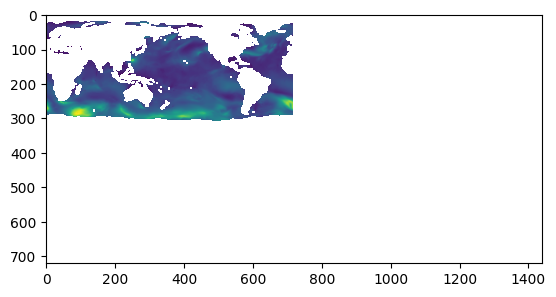

In [42]:
plt.clf()
plt.imshow(fields, cmap='viridis')

<Figure size 640x480 with 0 Axes>

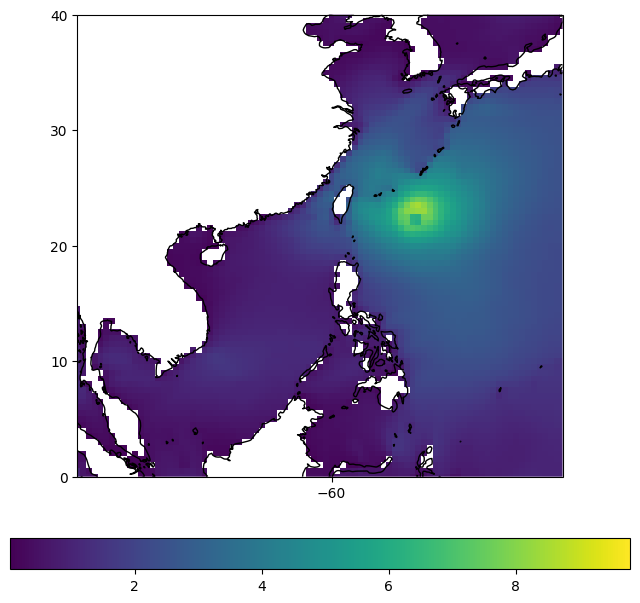

In [55]:
# start_time = "2015-09-20T00:00:00"  # 开始时间
# end_time = "2015-9-30T00:00:00"    # 结束时间
# fields = dataset['cdww'].sel(time=slice(start_time, end_time))


plt.clf()

fig = plt.figure(figsize=(16, 8))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.coastlines(resolution="50m")

ax.set_xticks(range(0, 361, 30), crs=ccrs.PlateCarree())
# ax.set_xticks(range(-180, 181, 30), crs=ccrs.PlateCarree())

ax.set_yticks(range(-90, 91, 10), crs=ccrs.PlateCarree())
# ax.gridlines(draw_labels=False)

# 假设 lat 和 lon 是纬度和经度的数组

# wind
# lat = np.linspace(90, -90, fields.shape[0])
# lon = np.linspace(0, 360, fields.shape[1])

#wave
lat = np.arange(90, -90, -0.5)
lon = np.arange(0, 360, 0.5)

lon, lat = np.meshgrid(lon, lat)

c = ax.pcolormesh(lon, lat, fields[:lat.shape[0],:lat.shape[1]], transform=ccrs.PlateCarree(), cmap='viridis')

plt.xlim([x-180 for x in [98,140]])
plt.ylim([0, 40])
plt.colorbar(c, ax=ax, orientation='horizontal', pad=0.1, shrink=0.5)


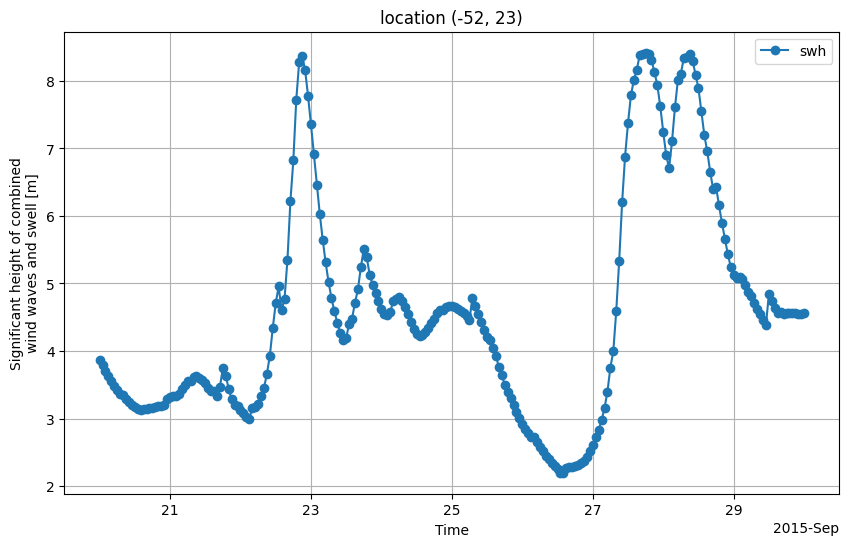

In [50]:
start_time = "2015-09-20T00:00:00"  # 开始时间
end_time = "2015-9-30T00:00:00"    # 结束时间
lon, lat = [128-180, 23]  # 经纬度

swh = dataset['swh'].sel(time=slice(start_time, end_time)).sel(longitude=lon, latitude=lat, method="nearest")
u10 = dataset['u10'].sel(time=slice(start_time, end_time)).sel(longitude=lon, latitude=lat, method="nearest")
u10n = dataset['u10n'].sel(time=slice(start_time, end_time)).sel(longitude=lon, latitude=lat, method="nearest")
sp = dataset['sp'].sel(time=slice(start_time, end_time)).sel(longitude=lon, latitude=lat, method="nearest")
msl = dataset['msl'].sel(time=slice(start_time, end_time)).sel(longitude=lon, latitude=lat, method="nearest")


# 绘制时间序列图
fig,ax = plt.subplots(figsize=(10, 6))
swh.plot(ax=ax, label='swh',marker='o')   

# u10.plot(ax=ax, label='u10') 
# u10n.plot(ax=ax, label='u10n')

# sp.plot(ax=ax, label='sp') 
# msl.plot(ax=ax, label='msl')

plt.title(f'location ({lon}, {lat})')
plt.xlabel('Time')
# plt.ylabel('hs')
ax.legend()
plt.grid(True)
plt.show()